In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from sklearn.cluster import AgglomerativeClustering

In [ ]:
# LANGKAH 1: LOAD DATA
df = pd.read_csv('/content/shopping_behavior_updated.csv')
df = df.drop_duplicates()

# LANGKAH 2: PREPROCESSING
# hapus duplikat
df = df.drop_duplicates()

# cek missing value
df.isnull().sum()
df = df.dropna()

In [ ]:
# mapping frekuensi belanja ke numerik
freq_map = {
    'Daily': 30,
    'Weekly': 4,
    'Fortnightly': 2,
    'Monthly': 1,
    'Quarterly': 0.33,
    'Annually': 0.08
}

df['Purchase_Frequency_Num'] = df['Frequency of Purchases'].map(freq_map)

df = df.dropna(subset=['Purchase_Frequency_Num'])

# K-MEANS CLUSTERING

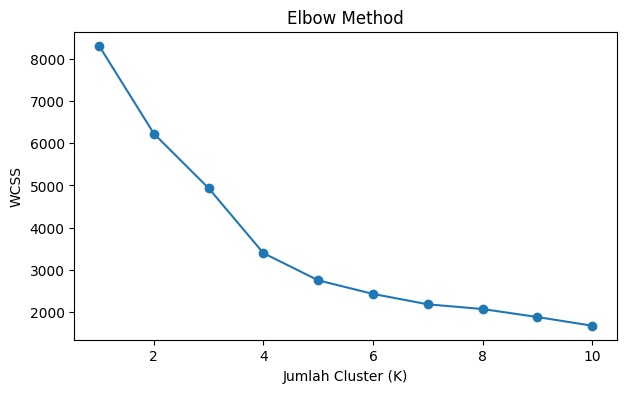

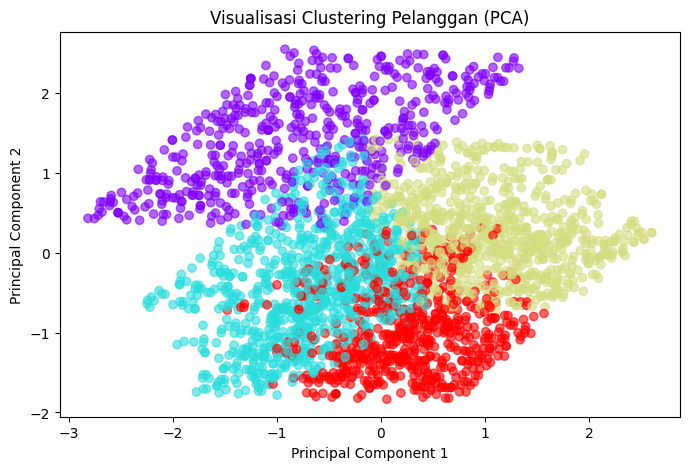

Silhouette Score: 0.31863543181343335


In [ ]:
X = df[['Age', 'Purchase_Frequency_Num', 'Purchase Amount (USD)']]

# Standarisasi K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ELBOW METHOD (WCSS)
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

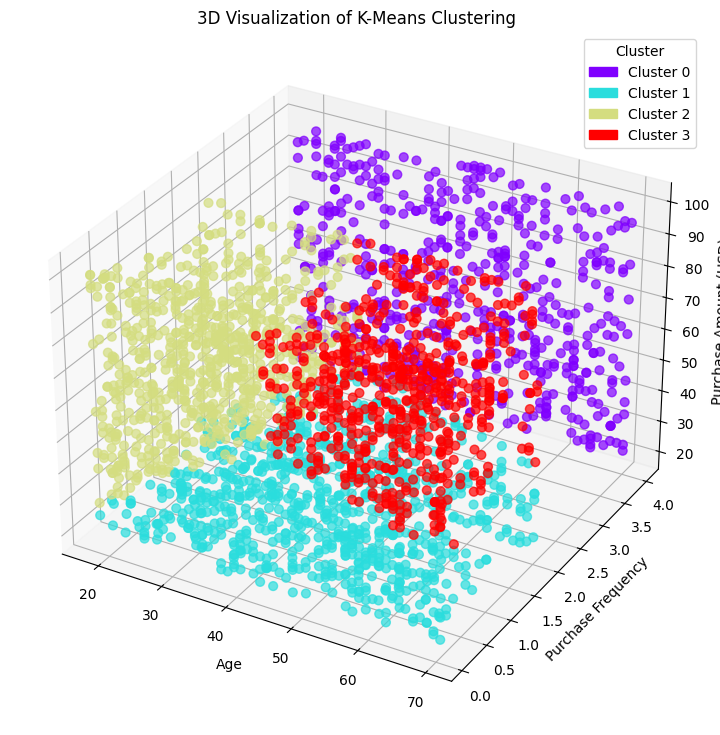

In [ ]:
# K-MEANS CLUSTERING
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# VISUALISASI K-MEANS PAKE 3D
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Purchase_Frequency_Num'],
    df['Purchase Amount (USD)'],
    c=df['Cluster'],
    cmap='rainbow',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Age')
ax.set_ylabel('Purchase Frequency')
ax.set_zlabel('Purchase Amount (USD)')
ax.set_title('3D Visualization of K-Means Clustering')

# nambahin label
clusters = np.sort(df['Cluster'].unique())
colors = scatter.cmap(scatter.norm(clusters))

legend_patches = [
    mpatches.Patch(color=colors[i], label=f'Cluster {clusters[i]}')
    for i in range(len(clusters))
]

ax.legend(handles=legend_patches, title='Cluster')

plt.show()

# LANGKAH 6: EVALUASI MODEL
sil_kmeans = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_kmeans)

## Profil Numerik

In [ ]:
# Profil numerik tiap cluster (K-Means)
cluster_profile = df.groupby('Cluster')[[
    'Age',
    'Purchase_Frequency_Num',
    'Purchase Amount (USD)'
]].mean()

cluster_profile


,Age,Purchase_Frequency_Num,Purchase Amount (USD)
Cluster,,,
0,44.649351,4.000000,58.972171
1,47.357477,0.865572,35.779206
2,29.252000,0.847227,71.444000
3,58.241987,0.788782,78.200321


**Cluster 0 – Pelanggan Loyal Menengah**
*  Rata-rata umur: dewasa menengah
*  Frekuensi belanja: tinggi
*  Total transaksi: menengah

Insight:

Cluster ini merupakan pelanggan yang rutin berbelanja dengan nilai transaksi stabil. strategi yang cocok adalah  program loyalitas, membership, dan promo berkelanjutan.

**Cluster 1 – Pelanggan Low Engagement**
*  Rata-rata umur: dewasa
*  Frekuensi belanja: rendah
*  Total transaksi: tinggi

Insight:

Cluster ini menunjukkan keterlibatan rendah dan berpotensi churn. Strategi yang disarankan adalah reaktivasi seperti diskon comeback dan reminder sangat disarankan.

**Cluster 2 – Pelanggan Muda Impulsif**
*  Rata-rata umur: muda
*  Frekuensi belanja: rendah
*  Total transaksi: tinggi

Insight:

Cluster ini cenderung melakukan pembelian impulsif dengan nilai besar. Strategi yang cocok adalah flash sale, promo berbasis tren, dan limited offer.

**Cluster 3 – Pelanggan Eksklusif Dewasa**
*  Rata-rata umur: tua
*  Frekuensi belanja: rendah
*  Total transaksi: paling tinggi

Insight:

Cluster ini memiliki daya beli tinggi dan cocok untuk penawaran eksklusif, layanan personal, dan produk premium.

## insight distribusi kategori produk paling banyak di beli per cluster

In [ ]:
# Distribusi kategori produk per cluster
category_dist = (
    df.groupby('Cluster')['Category']
      .value_counts(normalize=True)
      .rename('Proporsi')
      .reset_index()
)

print("\nDistribusi Kategori Produk per Cluster:")
category_dist.head(10)


Distribusi Kategori Produk per Cluster:


,Cluster,Category,Proporsi
0,0,Clothing,0.448980
1,0,Accessories,0.307978
2,0,Footwear,0.159555
3,0,Outerwear,0.083488
4,1,Clothing,0.420561
5,1,Accessories,0.317757
6,1,Footwear,0.161215
7,1,Outerwear,0.100467
8,2,Clothing,0.433333
9,2,Accessories,0.337333


In [ ]:
# CATEGORY TERDOMINAN PER CLUSTER
dominant_category = (
    df.groupby('Cluster')['Category']
      .agg(lambda x: x.value_counts().index[0])
)

dominant_category

,Category
Cluster,
0,Clothing
1,Clothing
2,Clothing
3,Clothing
